In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
sys.path.append('..')

import utilities.functions as functions


from utilities.functions import (
    summary,
    gerar_resumo_decis,
    resumo_coorte_ativa
 )
from utilities.graficos import (
  boxplot_meses
 
)
from utilities.outliers import(
    outlier_method,
    mark_outliers_iqr_zscore_mad
)
from pathlib import Path
BASE_PATH = Path("/Users/maceli/ifood_cs/dados") 


In [18]:
df = pd.read_parquet(BASE_PATH / "gold" / "df_publico.parquet")
df.head()

,customer_id,is_target,active,created_at,delivery_address_state,merchant_id,order_created_at,order_id,order_total_amount,origin_platform,...,num_pedidos_mes,num_pedidos_hist,outlier_iqr,outlier_zscore,outlier_mad,lim_inf_iqr,lim_sup_iqr,zscore,mad_score,id_p99
0,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,e80a8d7a13b52ca9ccf247ca3396f1018be41a5b014d79...,2019-01-11 14:07:48+00:00,c9a236fc0b0255433d0852dc90ef8b9949f3a3ab67e553...,10.0,ANDROID,...,17,19,False,False,False,0.01,84.15,-1.210558,-1.405208,0
1,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-05 13:38:28+00:00,db3b910b374ce240d551b829b297b9547f4e2feee9fd78...,12.0,ANDROID,...,17,19,False,False,False,0.01,84.15,-1.130823,-1.292792,0
2,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-13 13:50:06+00:00,a20903719abdaae9f6639681845f95963de83e0047ff13...,13.0,ANDROID,...,17,19,False,False,False,0.01,84.15,-1.090955,-1.236583,0
3,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-26 13:15:53+00:00,90652cc196fbfa352b1d4d61b18b5babf39fad949c7ccc...,13.0,ANDROID,...,17,19,False,False,False,0.01,84.15,-1.090955,-1.236583,0
4,755e1fa18f25caec5edffb188b13fd844b2af8cf5adedc...,target,True,2018-04-06T02:48:42.887Z,SP,05291eacc3cb88847b56af15838a0e653a1fcda54a1d88...,2019-01-15 13:48:33+00:00,9091a0ead77e2ed0d5ed9ce6787631386bd120036ff5b7...,13.0,ANDROID,...,17,19,False,False,False,0.01,84.15,-1.090955,-1.236583,0


In [3]:
id_both_monht=df[df['order_created_month']==12]['customer_id'].unique()
df = df[df['customer_id'].isin(id_both_monht)].reset_index(drop=True)


In [4]:
df_stats_mes = df.groupby(['order_created_month', 'is_target'])['order_total_amount'].agg(
    Média=('mean'),
    Mediana=('median'),
    Mínimo=('min'),
    Máximo=('max'),
    Desvio_Padrão=('std')
).round(2)
df_stats_mes['cv'] = (df_stats_mes['Desvio_Padrão'] / df_stats_mes['Média']).round(3)
df_stats_mes

Média  Mediana  Mínimo  Máximo  Desvio_Padrão  \
order_created_month is_target                                                  
1                   control    47.75     38.1    7.50   195.0          31.79   
                    target     40.36     35.0    8.15   192.7          25.11   
12                  control    49.30     38.0   11.00   168.0          33.13   
                    target     42.15     36.0    8.15   192.7          26.97   

                                  cv  
order_created_month is_target         
1                   control    0.666  
                    target     0.622  
12                  control    0.672  
                    target     0.640

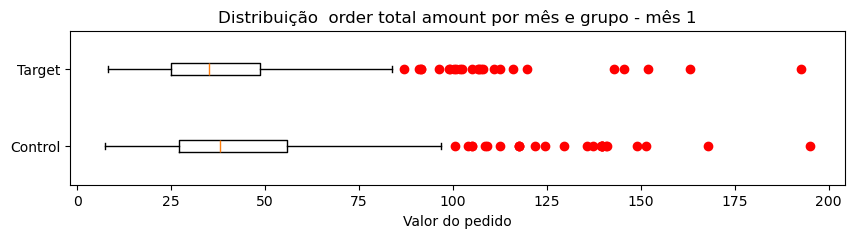

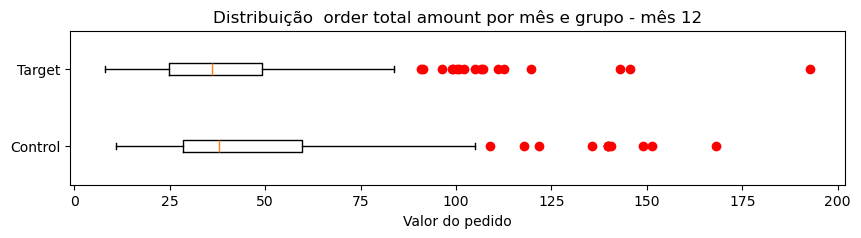

In [5]:
boxplot_meses(df, [1, 12])

In [6]:
outlier_method(df,var='order_total_amount')

Use MAD (assimétrico + robusto)


'mad'

In [7]:
df = mark_outliers_iqr_zscore_mad(df)


In [ ]:
#df.to_parquet(BASE_PATH / "gold" / "df_publico.parquet", index=False)

In [8]:
total_amount = df.groupby(['order_created_month','outlier_iqr','outlier_zscore','outlier_mad']).agg(
    total_pedidos=('unique_order_hash', 'nunique')
).round(2)
total_amount

total_pedidos
order_created_month outlier_iqr outlier_zscore outlier_mad               
1                   False       False          False                  672
                    True        False          False                    7
                                               True                    33
                                True           True                    11
12                  False       False          False                  325
                                               True                     3
                    True        False          False                    3
                                               True                    19
                                True           True                     6

In [9]:
df_outliers = df[
    df['outlier_iqr'] & 
    df['outlier_zscore'] & 
    df['outlier_mad']][['customer_id','order_created_month','order_total_amount','num_pedidos_hist','num_pedidos_mes']]


In [16]:
df_outliers.head()

,customer_id,order_created_month,order_total_amount,num_pedidos_hist,num_pedidos_mes
135,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,1,195.0,9,7
136,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,1,168.0,9,7
138,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,12,168.0,9,2
252,298bdef443cf4dd3614cffa088a939fa3d3ebad163d220...,1,163.0,14,8
253,298bdef443cf4dd3614cffa088a939fa3d3ebad163d220...,1,152.0,14,8


In [11]:
p99 = df['order_total_amount'].quantile(0.99)

acima_p99 = df[
    df['order_total_amount'] > p99
]

acima_p99[['customer_id','unique_order_hash','order_created_month','order_total_amount','outlier_iqr','outlier_zscore','outlier_mad']]

acima_p99['customer_id'].nunique()

4

In [12]:
id_p99=acima_p99['customer_id'].unique()

In [13]:
df['id_p99'] = df['customer_id'].isin(id_p99).astype(int)
df[df['id_p99']==1][['customer_id','unique_order_hash','order_created_month','order_total_amount','day','outlier_iqr','outlier_zscore','outlier_mad','id_p99']].head(10)

,customer_id,unique_order_hash,order_created_month,order_total_amount,day,outlier_iqr,outlier_zscore,outlier_mad,id_p99
131,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,6280395930853013257,1,47.00,26,False,False,False,1
132,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,8375403443903045600,1,81.70,23,False,False,False,1
133,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,4965369037086780196,1,69.40,22,False,False,False,1
134,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,13526963463313600868,1,112.50,25,True,False,True,1
135,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,7409692391608107439,1,195.00,28,True,True,True,1
136,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,12290574871276594958,1,168.00,5,True,True,True,1
137,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,9828447071624588389,1,44.72,22,False,False,False,1
138,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,5766135708987893934,12,168.00,6,True,True,True,1
139,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,16693794814942610970,12,44.72,23,False,False,False,1
252,298bdef443cf4dd3614cffa088a939fa3d3ebad163d220...,7811933497405761777,1,163.00,15,True,True,True,1


In [14]:
stats_p99_por_cliente = (
    df[df['id_p99'] == 1]
    .groupby(['customer_id','order_created_month','is_target'])['order_total_amount']
    .agg(
        total_transacoes='count',
        minimo='min',
        maximo='max',
        media='mean'
    )
    .reset_index()   # ISSO resolve seu problema
    .sort_values(by=['customer_id','total_transacoes'], ascending=[False,False])
)

stats_p99_por_cliente.head(10)




,customer_id,order_created_month,is_target,total_transacoes,minimo,maximo,media
6,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,1,control,7,44.72,195.00,102.617143
7,df4a3b2f7c0e259adb8e71e094405637810013013f4971...,12,control,2,44.72,168.00,106.360000
4,3e4e88a5858dbd9ec7df8ccdb30a81d93c8d9152f5c94c...,1,target,2,91.50,192.70,142.100000
5,3e4e88a5858dbd9ec7df8ccdb30a81d93c8d9152f5c94c...,12,target,1,192.70,192.70,192.700000
2,298bdef443cf4dd3614cffa088a939fa3d3ebad163d220...,1,target,8,67.80,163.00,117.287500
3,298bdef443cf4dd3614cffa088a939fa3d3ebad163d220...,12,target,6,67.80,145.50,103.883333
0,09e4def9729099ca5ecd0e95896290d78d21a2040d102d...,1,control,21,66.50,151.42,116.243333
1,09e4def9729099ca5ecd0e95896290d78d21a2040d102d...,12,control,10,80.16,151.42,129.443000


In [15]:
matriz_migracao(stats_p99_por_cliente,mes_0=12,mes_1=1,group_by_extra='total_transacoes').head(10)


NameError: name 'matriz_migracao' is not defined

In [ ]:
p10 = df['order_total_amount'].quantile(0.10)

abaixo_p10 = df[
    df['order_total_amount'] < p10
]

abaixo_p10[['customer_id','unique_order_hash','order_created_month','order_total_amount','outlier_iqr','outlier_zscore','outlier_mad']]

abaixo_p10['customer_id'].unique()


In [ ]:
id_p10=abaixo_p10['customer_id'].unique()
df['id_p10'] = df['customer_id'].isin(id_p10).astype(int)
df[df['id_p10']==1][['customer_id','unique_order_hash','order_created_month','order_total_amount','day','outlier_iqr','outlier_zscore','outlier_mad','id_p99']].head(10)
stats_p10_por_cliente = (
    df[df['id_p10'] == 1]
    .groupby(['customer_id','order_created_month','is_target'])['order_total_amount']
    .agg(
        total_transacoes='count',
        minimo='min',
        maximo='max',
        media='mean'
    )
    .reset_index()   # ISSO resolve seu problema
    .sort_values(by=['customer_id','total_transacoes'], ascending=[False,False])
)
stats_p10_por_cliente.head(10)

In [ ]:
abaixo_p10.columns

In [ ]:
df[df['customer_id']=='002ca070253de5dd983f577e0156dae30cfe981198bce5c7815755748343594c'][['customer_id','unique_order_hash','order_created_at','merchant_id','order_total_amount','outlier_iqr','outlier_zscore','outlier_mad']]

In [ ]:
# Calcular LTV histórico E total de pedidos
historico_cliente = df[df['customer_id'] == '002ca070253de5dd983f577e0156dae30cfe981198bce5c7815755748343594c']

ltv_historico = historico_cliente['order_total_amount'].sum()
total_pedidos = len(historico_cliente)
tempo_atividade = (historico_cliente['order_created_at'].max() - historico_cliente['order_created_at'].min()).days

# Calcular métricas derivadas
ticket_medio = ltv_historico / total_pedidos if total_pedidos > 0 else 0

# LTV mensal projetado
if tempo_atividade > 0:
    ltv_mensal = (ltv_historico / tempo_atividade) * 30
    ltv_anual_projetado = ltv_mensal * 12
    frequencia_mensal = (total_pedidos / tempo_atividade) * 30
else:
    ltv_anual_projetado = ltv_historico * 4
    frequencia_mensal = total_pedidos

print("📊 ANÁLISE COMPLETA DO CLIENTE:")
print(f"💰 LTV Histórico: R$ {ltv_historico:.2f}")
print(f"🛒 Total de Pedidos: {total_pedidos}")
print(f"📈 LTV Anual Projetado: R$ {ltv_anual_projetado:.2f}")
print(f"💵 Ticket Médio: R$ {ticket_medio:.2f}")
print(f"📅 Frequência Mensal: {frequencia_mensal:.1f} pedidos/mês")
print(f"⏰ Tempo de Atividade: {tempo_atividade} dias")

# Análise adicional
if total_pedidos > 0:
    print(f"\n🎯 MÉTRICAS AVANÇADAS:")
    print(f"• Valor por Dia: R$ {ltv_historico/tempo_atividade:.2f}" if tempo_atividade > 0 else "• Valor por Dia: N/A")
    print(f"• Pedidos por Dia: {total_pedidos/tempo_atividade:.3f}" if tempo_atividade > 0 else "• Pedidos por Dia: N/A")
    
    # Classificação do cliente
    if ltv_anual_projetado > 5000:
        classificacao = "💎 CLIENTE PREMIUM"
    elif ltv_anual_projetado > 2000:
        classificacao = "🥇 CLIENTE OURO" 
    elif ltv_anual_projetado > 1000:
        classificacao = "🥈 CLIENTE PRATA"
    else:
        classificacao = "👤 CLIENTE BÁSICO"
    
    print(f"• Classificação: {classificacao}")
